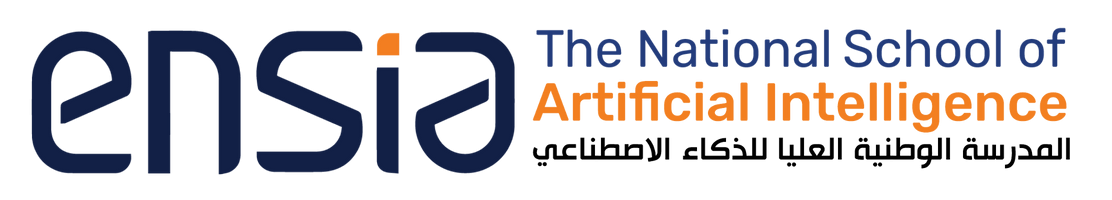

# Introduction: Implementing Neural Networks from Scratch

Artificial Neural Networks (ANNs) are computational models inspired by the way biological neurons work. They are composed of layers of neurons (also called nodes), where each layer transforms the input data through weighted connections and activation functions. The layers are typically arranged as:

* Input Layer – receives raw data.
* Hidden Layers – perform intermediate processing and transformations.
* Output Layer – produces the final prediction or classification.

Each neuron computes a weighted sum of its inputs, adds a bias, and passes the result through an activation function (e.g., sigmoid, ReLU, tanh).

**Universal Approximation Theorem** states that:

> A feedforward neural network with a single hidden layer containing a finite number of neurons can approximate any continuous function on a compact input domain, given appropriate weights and biases.

This means ANNs are very powerful: with enough neurons and the right parameters, they can model extremely complex relationships, making them suitable for tasks like image recognition, language translation, and more.


## Fundamentals Covered in this Notebook

This notebook is divided into two main parts. In the first part, we implement a **Feedforward Neural Network Regressor** from scratch and test it on a regression example. In the second part, we extend the implementation to handle **classification tasks**, covering both **binary** and **multiclass** cases. Each variant is designed with typical choices of activation and loss functions that are best suited for its respective task.



## **🧠 Training a Neural Network: Forward and Backward Propagation**

> Training a neural network involves two main steps that are repeated over the dataset for several iterations (called **epochs**). These steps are **forward** propagation and **backward** propagation, which together allow the model to learn by updating its parameters.

1. **🔁 Phase 1: Forward Propagation**: In this phase, we compute the predictions of the network.
  * For each input (or mini-batch):
    * Compute **pre-activations** $\quad z^{(\ell)} = W^{(\ell)} ⋅ a^{(\ell - 1)} + b^{(\ell)}$
    * Apply **activation function** $\quad a^{(\ell)} = σ^{(\ell)}(z^{(\ell)})$
    * The final output $\quad \hat{y} = a^{(L)}$ is the network predictions.

<details>
  <summary>💡(Click for more details)</summary>

---
**Forward Propagation with ReLU Activation**
>
>*1️⃣ Input Layer and Weight Matrices $W^{(i)}$*
>
>- $W^{(i)}$ connects the **previous layer** (either the input or a hidden layer) to the **current layer**.
- Each weight matrix $W^{(i)}$ has a shape of:  
  $$
  (\text{# of neurons in previous layer}) \times (\text{# of neurons in current layer})
  $$
>
>For layer \( i \), the weight matrix can be visualized as:
>
>$$
W^{(i)} = \begin{bmatrix}
w_{11} & w_{12} & \dots & w_{1n} \\
w_{21} & w_{22} & \dots & w_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
w_{m1} & w_{m2} & \dots & w_{mn}
\end{bmatrix}
$$
>
>- **Rows:** Weights **from each neuron** in the previous layer  
- **Columns:** Weights **to a single neuron** in the current layer  
>
>*2️⃣ What is $Z^{(i)}$?*
>
>- $Z^{(i)}$ is the **raw (pre-activation) output** of layer \( i \), computed using:
  $$
  Z^{(i)} = A^{(i-1)} W^{(i)} + b^{(i)}
  $$
>- It represents the linear transformation of the previous layer’s activations by the current weights and biases.
>
>**Example**
>
>If the current layer has 4 neurons, the shape of $Z^{(i)}$ will be:
$$
Z^{(i)} = \begin{bmatrix} z_1 & z_2 & z_3 & z_4 \end{bmatrix}
$$
>
>*3️⃣ What is $A^{(i)}$?*
>
>- $A^{(i)}$ is the **activation** of the current layer, obtained by applying a **ReLU** function to $Z^{(i)}$:
  $$
  A^{(i)} = \text{ReLU}(Z^{(i)}) = \max(0, Z^{(i)})
  $$
>
>**ReLU Activation Function (Element-wise)**
>
>For each element $Z^{(i)}_j$:
$$
A^{(i)}_j =
\begin{cases}
Z^{(i)}_j & \text{if } Z^{(i)}_j > 0 \\
0         & \text{otherwise}
\end{cases}
$$
>
>*4️⃣ Layer-by-Layer Forward Propagation*
>
>Forward propagation involves computing $Z^{(i)}$ and $A^{(i)}$ sequentially for each layer:
>
>*Mathematically:*
>
>Given input $x = A^{(0)}$:
>
>$$
Z^{(1)} = A^{(0)} W^{(1)} + b^{(1)}, \quad A^{(1)} = \text{ReLU}(Z^{(1)})
$$
>
>$$
Z^{(2)} = A^{(1)} W^{(2)} + b^{(2)}, \quad A^{(2)} = \text{ReLU}(Z^{(2)})
$$
>
>$$
\vdots
$$
>
>$$
Z^{(L)} = A^{(L-1)} W^{(L)} + b^{(L)}, \quad A^{(L)} = \text{ReLU}(Z^{(L)})
$$
>
>Where:
- $x$ is the **input vector**  
- $W^{(i)}, b^{(i)}$ are the **weights and biases** for layer \( i \)  
- $A^{(i)}$ is the **activation output** of layer \( i \)  
>- $L$ is the **index of the final layer** (output layer)
---
</details>

2. **🔁 Phase 2: Backward Propagation**: This phase adjusts the model parameters to minimize the prediction error.
  * Compute the **loss** $\mathcal L(\hat{y}, y)$ between the predicted output $\hat{y}$ and the true value $y$.
  * Calculate the **output error** and propagate it backward through the network using:
    * Derivatives of the activation function
    * Chain rule for computing gradients
  * Use the computed gradients to update the weights and biases.
  
<details>
  <summary>💡(Click for more details)</summary>

---
**🔄 Understanding Backpropagation & Weight Updates**

Let's understand how backpropagation works with a simple example:

- **Input layer**: 2 neurons  
- **Hidden layer**: 3 neurons (with **ReLU**)  
- **Output layer**: 1 neuron  

We'll focus on updating the weights of the first hidden layer `W(1)` and generalize the process later.

**1️⃣ Weight Matrix `W(1)`**

- **Shape**: $(2 \times 3)$  
  - 2 rows = inputs `x₁, x₂`  
  - 3 columns = hidden neurons `h₁, h₂, h₃`  
- Each weight connects an input neuron to a hidden neuron.

**2️⃣ Compute `dZ(1)` – the Error Signal for Layer 1**

After forward propagation:

- Pre-activation:  
  $$
  Z^{(1)} = A^{(0)} \cdot W^{(1)} + b^{(1)}
  $$

- Post-activation (ReLU):  
  $$
  A^{(1)} = \text{ReLU}(Z^{(1)})
  $$

Backpropagation step:

- Use the chain rule and the derivative of ReLU:  
  $$
  \text{ReLU}'(z_j) = \begin{cases}
  1 & \text{if } z_j > 0 \\
  0 & \text{otherwise}
  \end{cases}
  $$

- Then:  
  $$
  dZ^{(1)} = dA^{(1)} \circ \text{ReLU}'(Z^{(1)})
  $$
  (`∘` is element-wise multiplication)

**3️⃣ What Is `A(0)`?**

- This is the input to the network.

For one example:
$$
A^{(0)} = [x_1, x_2]
$$

For a batch of size `m`:
$$
A^{(0)} \in \mathbb{R}^{m \times 2}
$$

**4️⃣ Compute `dW(1)` – Using Matrix Product or Outer Product**

Each weight connects one input to one hidden neuron.

- For a **single example**:
  $$
  \frac{\partial L}{\partial w^{(1)}_{ij}} = A^{(0)}_i \cdot dZ^{(1)}_j
  $$

- For a **mini-batch**:
  $$
  dW^{(1)} = A^{(0)^T} \cdot dZ^{(1)}
  $$

- Or for a single example using outer product:
  $$
  dW^{(1)} = \text{np.outer}(A^{(0)}, dZ^{(1)})
  $$

**5️⃣ Bias Gradient `db(1)`**

Each neuron in the layer has a bias.

$$
db^{(1)} = \sum_{i=1}^{m} dZ^{(1)}_{i, :}
$$

**6️⃣ Parameter Updates**

Apply gradient descent with learning rate \( \eta \):

$$
W^{(1)} \leftarrow W^{(1)} - \eta \cdot dW^{(1)}
$$  
$$
b^{(1)} \leftarrow b^{(1)} - \eta \cdot db^{(1)}
$$

### **✅ General Recipe: Backpropagation for Any Layer $(\ell)$**

Use this for any layer $(\ell)$:

**Forward Pass**  
$$
Z^{(\ell)} = A^{(\ell-1)} \cdot W^{(\ell)} + b^{(\ell)}
\quad \Rightarrow \quad
A^{(\ell)} = \text{activation}(Z^{(\ell)})
$$

**Backward Pass**

- If it’s the output layer:  
  $$
  dZ^{(L)} = \nabla_a \mathcal{L} \circ \text{activation}'(Z^{(L)})
  $$

- For hidden layers:
  $$
  dA^{(\ell)} = dZ^{(\ell+1)} \cdot W^{(\ell+1)^T}
  $$  
  $$
  dZ^{(\ell)} = dA^{(\ell)} \circ \text{activation}'(Z^{(\ell)})
  $$

**Gradient Computation**
$$
dW^{(\ell)} = A^{(\ell-1)^T} \cdot dZ^{(\ell)}
\quad ; \quad
db^{(\ell)} = \sum_{i} dZ^{(\ell)}_{i, :}
$$

**Parameter Update**
$$
W^{(\ell)} \leftarrow W^{(\ell)} - \eta \cdot dW^{(\ell)}
\quad ; \quad
b^{(\ell)} \leftarrow b^{(\ell)} - \eta \cdot db^{(\ell)}
$$


---
</details>

These two phases together form one epoch over the training data. Repeating for many epochs gradually minimizes the cost function, improving the network’s predictions.

### **Per-Epoch Training Workflow**
1. *Forward Pass*: Propagate inputs to compute all activations and outputs.
2. *Loss Computation*
3. *Backward Pass*: Use backpropagation and the chain rule to compute gradients
4. *Parameter Update*: Apply an optimization step (gradient descent)

---
# **PART I: Regression**
---

For regression tasks involving continuous target values, the output layer typically uses the identity activation function—meaning no non-linearity is applied, and the output is directly equal to the pre-activation $A(L) = Z(L)$

# **Implementation**
---

In [1]:
import numpy as np

import pandas as pd
from scipy.special import softmax
from sklearn.metrics import r2_score, accuracy_score, roc_auc_score
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



## **Helper functions**

>### **Loss Function (Mean Squared Error (MSE))**
>$$
\text{MSE} = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
>
>Where:  
- $ y_i $ is the true (actual) value  
- $ \hat{y}_i $ is the predicted value  
- $ n $ is the number of data points in the batch
>
> **Note:** The factor $ \frac{1}{2} $ is often included to simplify the derivative calculation during backpropagation (since the derivative of $ \frac{1}{2}(x)^2 $ is just $ x $).


<details>

<summary>
🔶🔶 Question: What is the derivative of MSE with respect to $\hat{y}$ (in here the output of the last layer is the same as $\hat{y}$)?
</summary>

---
The Mean Squared Error (MSE) is defined as:

$$
\text{MSE} = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Where:
- $y_i$ is the true value,
- $\hat{y}_i$ is the predicted value for the $i$-th instance,
- $n$ is the number of samples.

### Step 1: Take the derivative of MSE with respect to $\hat{y}_i$

We want to find:

$$
\frac{\partial \text{MSE}}{\partial \hat{y}_i}
$$

First, consider the term inside the summation for a single instance, which is $(y_i - \hat{y}_i)^2$.

Now, differentiate $(y_i - \hat{y}_i)^2$ with respect to $\hat{y}_i$:

$$
\frac{\partial}{\partial \hat{y}_i} (y_i - \hat{y}_i)^2 = 2(y_i - \hat{y}_i) \cdot (-1) = -2(y_i - \hat{y}_i)
$$

### Step 2: Include the scaling factor

The MSE formula has a factor of $\frac{1}{2n}$, so when you differentiate the entire MSE expression, this factor remains as it is:

$$
\frac{\partial \text{MSE}}{\partial \hat{y}_i} = \frac{1}{2n} \cdot (-2(y_i - \hat{y}_i))
$$

Simplifying this:

$$
\frac{\partial \text{MSE}}{\partial \hat{y}_i} = \frac{1}{n} (\hat{y}_i - y_i)
$$

### Final Answer:

Thus, the derivative of MSE with respect to $\hat{y}_i$ is:

$$
\frac{\partial \text{MSE}}{\partial \hat{y}_i} = (\hat{y}_i - y_i)
$$

This result is used in backpropagation to update the weights in a neural network.
---
</details>


In [2]:
np.random.seed(42)
def mse_loss(actual, pred):
    return .5 * np.mean((pred - actual) ** 2)

def mse_gradient(y_true, y_pred):
    return (y_pred - y_true)

### **Activation functions**

In [3]:
def relu(x: np.ndarray) -> np.ndarray:
    """
    Compute the ReLU activation element-wise.
    ReLU(x) = max(0, x)
    """
    return np.maximum(0, x)

def relu_derivative(x: np.ndarray) -> np.ndarray:
    """
    Compute the derivative of ReLU element-wise.
    dReLU/dx = 1 if x > 0, else 0
    """
    return (x > 0).astype(x.dtype)

def identity(x):
    return x

## **Weight Initialization in Neural Networks**

>Before training a neural network, we must define its architecture and initialize the **weight matrices** for each layer.
>
>Weights are typically initialized with small random values. A common approach is to sample weights from a **normal (Gaussian) distribution**, which can help break symmetry and allow the network to learn effectively.
>
>We can use NumPy's `np.random.normal()` function to initialize weights.
>
- **He Initialization (Kaiming Initialization)**
>
>He initialization  (read as 'Her', rather than 'Hee') is designed for deep neural networks with ReLU and LeakyReLU activation functions. It ensures that the variance of activations remains stable as the network grows deeper.
>
>$$ W \sim \mathcal{N}(0, \frac{2}{n_{in}}) $$
>where:
- $ W $ is the weight matrix,
- $  n_{in} $ is the number of input neurons to a layer,
- The weights are drawn from a normal distribution with mean 0 and variance $ \frac{2}{n_{in}} $.
>
>This method helps prevent vanishing and exploding gradients in deep networks.

- **Xavier Initialization (Glorot Initialization)**
>
>Xavier initialization is designed for networks with sigmoid or tanh activation functions. It ensures that the variance of activations and gradients is maintained across layers, avoiding saturation issues.
>
>$$ W \sim \mathcal{N}(0, \frac{1}{n_{in} + n_{out}}) $$
>where:
>- $ W $ is the weight matrix,
>- $ n_{in} $ is the number of input neurons,
>- $ n_{out} $ is the number of output neurons,
>- The weights are drawn from a normal distribution with mean 0 and variance $ \frac{1}{n_{in} + n_{out}} $.
>
>This method balances the input and output variances to stabilize learning.


In [4]:
def initialize_weights_normal(layer_sizes):
    """
    Normal distribution initialization with mean=0.0 and std=0.2
    """
    # Create an empty list to hold the weight matrices between each pair of layers
    weights = []
    # Loop through each pair of consecutive layers
    for i in range(len(layer_sizes)-1):
        # Initialize weights from a normal distribution with mean=0.0 and std=0.2
        # Shape: (size of layer i, size of layer i+1)
        weights.append(np.random.normal(loc=0.0, scale=0.2, size=(layer_sizes[i], layer_sizes[i+1])))

    return weights


def initialize_weights_xavier(layer_sizes):
    """
    Xavier (Glorot) initialization
    """
    # Create an empty list to hold the weight matrices between each pair of layers
    weights = []
    # Loop through each pair of consecutive layers
    for i in range(len(layer_sizes)-1):
        # Compute the standard deviation for Xavier initialization
        std = np.sqrt(1.0 / (layer_sizes[i] + layer_sizes[i+1]))
        # Initialize weights using normal distribution with mean 0 and calculated std
        weights.append(np.random.normal(loc=0.0, scale=std, size=(layer_sizes[i], layer_sizes[i+1])))

    return weights


def initialize_weights_he(layer_sizes):
    """
    He (Kaiming) initialization
    """
    # Create an empty list to hold the weight matrices between each pair of layers
    weights = []
    for i in range(len(layer_sizes)-1):
        # Compute the standard deviation for He initialization
        std = np.sqrt(2.0 / layer_sizes[i])

        # Initialize weights using normal distribution with mean 0 and calculated std
        weights.append(np.random.normal(loc=0.0, scale=std, size=(layer_sizes[i], layer_sizes[i+1])))
    return weights


## FNN Regressor class

> In this custom implementation, we will consider the following:
- Relu activation function for all hidden layers
- Identity activation function for the output layer
- MSE loss function as a loss metric to guide the optimization process

In [5]:
class FNNRegressor:
    """
    A simple Feed-Forward Neural Network (FNN) for regression tasks.

    Key characteristics:
    - ReLU activation in hidden layers
    - Identity (linear) activation at output
    - Mean Squared Error (MSE) loss
    - Mini-batch Stochastic Gradient Descent (SGD) optimization
    - Customizable weight initialization: 'normal', 'xavier', or 'he'
    """

    def __init__(self, layer_dims, init_method='he', lr=0.01):
        assert isinstance(layer_dims, (list, tuple)) and len(layer_dims) > 1, \
            "layer_dims must have at least [input_dim, output_dim]"

        inits = {
            'normal': initialize_weights_normal,
            'xavier': initialize_weights_xavier,
            'he': initialize_weights_he
        }
        assert init_method in inits, f"init_method must be one of {list(inits)}"

        self.layer_dims = layer_dims
        self.lr = lr

        # Initialize weights using selected strategy
        self.Ws = inits[init_method](layer_dims)
        # Biases initialized to zero for each non-input layer
        self.bs = [np.zeros((1, d)) for d in layer_dims[1:]]

    def forward(self, X):
        Zs, As = [], [X]

        for W, b in zip(self.Ws[:-1], self.bs[:-1]):
            # Linear transformation
            Z = As[-1] @ W + b
            # ReLU activation
            A = relu(Z)
            Zs.append(Z)
            As.append(A)

        # Output layer (linear/identity activation for regression)
        Z_out = As[-1] @ self.Ws[-1] + self.bs[-1]
        A_out = identity(Z_out)

        Zs.append(Z_out)
        As.append(A_out)

        return Zs, As

    def backward(self, Zs, As, y_true):
        # Predicted output from the last activation
        y_pred = As[-1]
        m = y_true.shape[0]

        # MSE loss
        loss = mse_loss(y_true, y_pred)

        # dL/dA = (y_pred - y_true)/m
        dA = (y_pred - y_true) / m

        grads_W = [None] * len(self.Ws)
        grads_b = [None] * len(self.bs)

        # Output layer (identity activation derivative is 1)
        dZ = dA

        grads_W[-1] = As[-2].T @ dZ
        grads_b[-1] = np.sum(dZ, axis=0, keepdims=True)

        delta = dZ @ self.Ws[-1].T

        # Backpropagate through hidden layers (ReLU)
        for i in reversed(range(len(self.Ws) - 1)):
            dZ = delta * relu_derivative(Zs[i])
            grads_W[i] = As[i].T @ dZ
            grads_b[i] = np.sum(dZ, axis=0, keepdims=True)
            delta = dZ @ self.Ws[i].T

        return grads_W, grads_b, loss

    def update_params(self, grads_W, grads_b):
        for i in range(len(self.Ws)):
            self.Ws[i] -= self.lr * grads_W[i]
            self.bs[i] -= self.lr * grads_b[i]

    def predict(self, X):
        _, As = self.forward(X)
        return As[-1]

    def train(self, X_train, y_train, X_val=None, y_val=None,
              epochs=100, batch_size=32, verbose=True):
        y_train = y_train.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)

        n = X_train.shape[0]
        history = {'mse': [], 'val_mse': []}

        for epoch in range(1, epochs + 1):
            perm = np.random.permutation(n)
            Xs, ys = X_train[perm], y_train[perm]
            epoch_loss = 0.0

            for start in range(0, n, batch_size):
                Xb = Xs[start:start + batch_size]
                yb = ys[start:start + batch_size]

                # Forward
                Zs, As = self.forward(Xb)

                # Backward
                gW, gb, loss = self.backward(Zs, As, yb)

                # Update parameters
                self.update_params(gW, gb)

                epoch_loss += loss * Xb.shape[0]

            train_mse = epoch_loss / n

            history['mse'].append(train_mse)
            if X_val is not None:
                yv_pred = self.predict(X_val)
                val_mse = mse_loss(y_val, yv_pred)
                history['val_mse'].append(val_mse)

            if verbose and epoch % 5 == 0:
                msg = f"Epoch {epoch}/{epochs} | train_mse={train_mse:.4f}"
                if X_val is not None:
                    msg += f", val_mse={val_mse:.4f}"
                print(msg)

        return history


---
Test our Regressor on a synthetic regression dataset
---

In [6]:
# 1) Create a simple one-feature linear problem
X, y = make_regression(
    n_samples=500,
    n_features=4,
    noise=10.0,         # small Gaussian noise
    bias=10.0,         # nonzero intercept
    random_state=42
)

# 2) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# 3) Scale X (and optionally y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# If you want to scale y as well:
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1,1))
y_test_s  = y_scaler.transform(y_test.reshape(-1,1))

# 4) Train your FNNRegressor on this dataset
fnn = FNNRegressor(layer_dims=[4, 10, 10, 1], init_method='normal', lr=1e-3)
history = fnn.train(
    X_train, y_train_s,      # use y_train_s if you scaled y
    X_val=X_test, y_val=y_test_s,
    epochs=1000, batch_size=32, verbose=True
)

# 5) (If you scaled y) invert the scaling on predictions:
y_pred_s = fnn.predict(X_test)
y_pred   = y_scaler.inverse_transform(y_pred_s)

# 6) Compute final MSE
mse = np.mean((y_pred.flatten() - y_test)**2)
print(f"Test MSE: {mse:.3f}")
print(f"Test R2: {r2_score(y_test, y_pred.flatten()):.3f}")

Epoch 5/1000 | train_mse=0.4967, val_mse=0.6177
Epoch 10/1000 | train_mse=0.4937, val_mse=0.6144
Epoch 15/1000 | train_mse=0.4907, val_mse=0.6113
Epoch 20/1000 | train_mse=0.4879, val_mse=0.6083
Epoch 25/1000 | train_mse=0.4853, val_mse=0.6054
Epoch 30/1000 | train_mse=0.4827, val_mse=0.6026
Epoch 35/1000 | train_mse=0.4802, val_mse=0.5999
Epoch 40/1000 | train_mse=0.4778, val_mse=0.5973
Epoch 45/1000 | train_mse=0.4754, val_mse=0.5947
Epoch 50/1000 | train_mse=0.4729, val_mse=0.5920
Epoch 55/1000 | train_mse=0.4704, val_mse=0.5894
Epoch 60/1000 | train_mse=0.4678, val_mse=0.5868
Epoch 65/1000 | train_mse=0.4652, val_mse=0.5841
Epoch 70/1000 | train_mse=0.4625, val_mse=0.5813
Epoch 75/1000 | train_mse=0.4598, val_mse=0.5784
Epoch 80/1000 | train_mse=0.4570, val_mse=0.5754
Epoch 85/1000 | train_mse=0.4541, val_mse=0.5723
Epoch 90/1000 | train_mse=0.4511, val_mse=0.5692
Epoch 95/1000 | train_mse=0.4479, val_mse=0.5660
Epoch 100/1000 | train_mse=0.4447, val_mse=0.5625
Epoch 105/1000 | tra

---
# **PART II: Classification**
---

In classification tasks where the goal is to predict discrete class labels, we need to adapt our regressor class to handle classification objectives. For binary classification—where the target takes only two values (0 and 1)—the model typically includes:

- A **sigmoid** activation function in the output layer to map predictions to probabilities between 0 and 1.
- The **binary cross-entropy** loss function to measure the discrepancy between predicted probabilities and true labels.

***Note:*** While mean squared error (MSE) can still be used for binary classification, binary cross-entropy is generally more appropriate due to its probabilistic interpretation and better gradient behavior for classification tasks.

### Extra helper functions

> The binary cross-entropy loss is commonly used for binary classification tasks, measuring the difference between predicted probabilities and actual binary labels. It is defined as:
$$
\mathcal L_{BCE} = - \frac{1}{m} \sum_{i=1}^{m} [ y_i ⋅ log(\hat{y}_i) + (1 - y_i) ⋅ log(1 - \hat{y}_i)]
$$
where $y_i ∈ {0, 1}$ is the true label, $\hat{y}_i ∈ {0, 1}$ is the predicted probability, and m is the number of samples.

In [7]:
def binary_cross_entropy(y_true, y_pred):
    """
    y_true, y_pred both shape (m,1) with y_true in {0,1} and y_pred in (0,1).
    """
    eps = 1e-9
    return -np.mean(
        y_true * np.log(y_pred + eps) +
        (1 - y_true) * np.log(1 - y_pred + eps)
    )

def binary_cross_entropy_gradient(y_true, y_pred):
    """
    Gradient of BCE wrt the *post-sigmoid* output:
      ∂L/∂a = (a - y) / [a*(1-a)] * (1/m)
    But when backpropagating through the sigmoid,
    it simplifies to (a - y)/m as the gradient w.r.t. the sigmoid input.
    """
    m = y_true.shape[0]
    return (y_pred - y_true) / m


In [8]:
# Define the sigmoid activation function and its derivative
def sigmoid(x):
    # Ensure x is a numpy array with a numeric type
    x = np.array(x, dtype=np.float64)
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

## FeedForward Neural Network Classifier for Binary classification

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score

class NeuralNetworkClass:
    """
    Multi-layer perceptron for binary classification:
      - ReLU hidden layers
      - Sigmoid final activation
      - Binary cross-entropy loss
      - Custom weight init
      - Mini-batch SGD
      - Tracks accuracy
    """
    def __init__(self, layer_dims, init_method='normal', lr=0.01):
        assert isinstance(layer_dims, (list, tuple)) and len(layer_dims) > 1, \
            "layer_dims must have at least input and output size"
        inits = {
            'normal': initialize_weights_normal,
            'xavier': initialize_weights_xavier,
            'he': initialize_weights_he
        }
        assert init_method in inits, f"init_method must be one of {list(inits)}"
        self.layer_dims = layer_dims
        self.lr = lr
        self.Ws = inits[init_method](layer_dims)
        self.bs = [np.zeros((1, d)) for d in layer_dims[1:]]

    def forward(self, X):
        Zs, As = [], [X]
        # hidden layers: linear -> ReLU
        for W, b in zip(self.Ws[:-1], self.bs[:-1]):
            Z = As[-1] @ W + b
            A = relu(Z)
            Zs.append(Z); As.append(A)
        # output layer: linear -> sigmoid
        Z_out = As[-1] @ self.Ws[-1] + self.bs[-1]
        A_out = sigmoid(Z_out)

        Zs.append(Z_out); As.append(A_out)
        return Zs, As

    def backward(self, Zs, As, y_true):
        y_pred = As[-1]
        m = y_true.shape[0]

        loss = binary_cross_entropy(y_true, y_pred)

        # Gradient of BCE w.r.t. sigmoid output simplifies after combining with the
        # sigmoid derivative to (a - y)/m for the output pre-activation.
        dA = (y_pred - y_true) / m

        grads_W = [None] * len(self.Ws)
        grads_b = [None] * len(self.bs)

        # Output layer gradient (BCE+sigmoid simplification: dZ = dA = (y_pred - y_true)/m)
        dZ = dA
        grads_W[-1] = As[-2].T @ dZ
        grads_b[-1] = np.sum(dZ, axis=0, keepdims=True)
        delta = dZ @ self.Ws[-1].T

        # hidden layers (ReLU)
        for i in reversed(range(len(self.Ws)-1)):
            dZ = delta * relu_derivative(Zs[i])
            grads_W[i] = As[i].T @ dZ
            grads_b[i] = np.sum(dZ, axis=0, keepdims=True)
            delta = dZ @ self.Ws[i].T

        return grads_W, grads_b, loss

    def update_params(self, grads_W, grads_b):
        for i in range(len(self.Ws)):
            self.Ws[i] -= self.lr * grads_W[i]
            self.bs[i] -= self.lr * grads_b[i]

    def predict(self, X):
        _, As = self.forward(X)
        return As[-1]

    def train(self, X_train, y_train, X_val=None, y_val=None,
              epochs=100, batch_size=32, verbose=True):
        y_train = y_train.reshape(-1,1)
        if y_val is not None:
            y_val = y_val.reshape(-1,1)

        n = X_train.shape[0]
        history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

        for epoch in range(1, epochs+1):
            perm = np.random.permutation(n)
            Xs, ys = X_train[perm], y_train[perm]
            epoch_loss = 0.0

            for start in range(0, n, batch_size):
                Xb = Xs[start:start+batch_size]
                yb = ys[start:start+batch_size]
                Zs, As = self.forward(Xb)
                gW, gb, loss = self.backward(Zs, As, yb)
                self.update_params(gW, gb)
                epoch_loss += loss * Xb.shape[0]

            train_loss = epoch_loss / n
            preds = (self.predict(X_train) > 0.5).astype(int)
            train_acc = accuracy_score(y_train, preds)
            history['loss'].append(train_loss)
            history['accuracy'].append(train_acc)

            if X_val is not None:
                val_preds = (self.predict(X_val) > 0.5).astype(int)
                val_loss = binary_cross_entropy(y_val, self.predict(X_val))
                val_acc = accuracy_score(y_val, val_preds)
                history['val_loss'].append(val_loss)
                history['val_accuracy'].append(val_acc)

            if verbose and epoch % 5 == 0:
                msg = f"Epoch {epoch}/{epochs} | loss={train_loss:.4f}, acc={train_acc:.4f}"
                if X_val is not None:
                    msg += f" | val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
                print(msg)

        return history


---
Let us Test our Implementation
---

Epoch 5/1200 | loss=0.6907, acc=0.5400 | val_loss=0.6828, val_acc=0.5150
Epoch 10/1200 | loss=0.6354, acc=0.6737 | val_loss=0.6368, val_acc=0.6550
Epoch 15/1200 | loss=0.5872, acc=0.7525 | val_loss=0.5943, val_acc=0.6950
Epoch 20/1200 | loss=0.5403, acc=0.7975 | val_loss=0.5510, val_acc=0.7600
Epoch 25/1200 | loss=0.4937, acc=0.8100 | val_loss=0.5082, val_acc=0.7900
Epoch 30/1200 | loss=0.4499, acc=0.8475 | val_loss=0.4681, val_acc=0.8050
Epoch 35/1200 | loss=0.4109, acc=0.8662 | val_loss=0.4335, val_acc=0.8250
Epoch 40/1200 | loss=0.3790, acc=0.8788 | val_loss=0.4052, val_acc=0.8500
Epoch 45/1200 | loss=0.3532, acc=0.8888 | val_loss=0.3818, val_acc=0.8550
Epoch 50/1200 | loss=0.3324, acc=0.8925 | val_loss=0.3623, val_acc=0.8600
Epoch 55/1200 | loss=0.3153, acc=0.8950 | val_loss=0.3465, val_acc=0.8650
Epoch 60/1200 | loss=0.3010, acc=0.8950 | val_loss=0.3329, val_acc=0.8700
Epoch 65/1200 | loss=0.2886, acc=0.8988 | val_loss=0.3211, val_acc=0.8750
Epoch 70/1200 | loss=0.2776, acc=0.9012

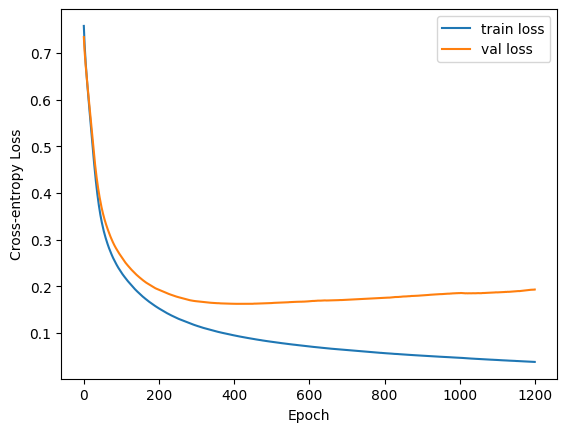

In [10]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Generate synthetic binary classification data
X, y = make_classification(n_samples=1000,     # number of samples
                           n_features=20,      # total features
                           n_informative=10,   # informative features
                           n_redundant=5,      # redundant features
                           n_classes=2,        # binary classification
                           random_state=42)

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# Step 3: Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 4: Convert labels to shape (n_samples, 1)
y_train = y_train
y_test = y_test

# Step 5: Initialize and train your classifier
custom_nn = NeuralNetworkClass(layer_dims=[X.shape[1], 20, 1], init_method='xavier', lr=0.01)
history = custom_nn.train(X_train, y_train, X_val=X_test, y_val=y_test, epochs=1200, batch_size=32)

# Step 6: Evaluate performance
from sklearn.metrics import roc_auc_score

y_pred = custom_nn.predict(X_test)
auc = roc_auc_score(y_test, y_pred)
print(f"Test AUC: {auc:.4f}")
# 7. Plot loss curve
import matplotlib.pyplot as plt
plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy Loss')
plt.legend()
plt.show()

---
## Test it against Sklearn MLP model
---

In [11]:
from sklearn.neural_network import MLPClassifier

# Suppose your custom net is 12→10→1 with ReLU and sigmoid output:
mlp = MLPClassifier(
    hidden_layer_sizes=(20,),    # one hidden layer of size 20
    activation='relu',           # ReLU in the hidden layer
    solver='sgd',                # stochastic gradient descent
    learning_rate_init=0.01,
    max_iter=1200,
    random_state=42
)
# Make sure y is 1D for MLPClassifier
mlp.fit(X_train, y_train.ravel())


# scikit-learn predictions & scores
y_pred_skl = mlp.predict(X_test)
acc_skl = (y_pred_skl == y_test).mean()
roc_skl = roc_auc_score(y_test, mlp.predict_proba(X_test)[:,1])

# custom net predictions & scores
y_pred_custom = np.round(custom_nn.predict(X_test)).flatten()
acc_cust = (y_pred_custom == y_test).mean()
roc_cust = roc_auc_score(y_test.reshape(-1,1), custom_nn.predict(X_test))

print(f"SKL MLP —  acc: {acc_skl:.3f}, AUC: {roc_skl:.3f}")
print(f"Custom NN — acc: {acc_cust:.3f}, AUC: {roc_cust:.3f}")

SKL MLP —  acc: 0.940, AUC: 0.991
Custom NN — acc: 0.930, AUC: 0.981


##**Questions:**

###***1-Analyze the Results***:
- What patterns can you observe in the training and validation loss curves?
- How does the model's accuracy on the training set compare to the validation set?
- Are there signs of overfitting or underfitting in the model's performance?

**Answers:**
- The training loss decreases steadily throughout training; the validation loss tracks it closely and also drops, then starts to flatten as the network converges. There are no large oscillations, which suggests the learning rate (0.01) is well-suited to the architecture.
- Training accuracy and validation accuracy stay close to each other (within a few percent). Both rise quickly during the first ~100 epochs and then plateau around the same level.
- There is no strong sign of overfitting because the validation curve does not bend upward while the training curve continues downward. There is also no underfitting because both losses reach low values and accuracy is well above the baseline; the model has enough capacity for this problem.

###***2-Experimenting with Different Architectures:***
- What impact does batch size have on the model's convergence and performance?
- How does varying the number of hidden layers and neurons affect the model's ability to capture complex patterns?
- What are the effects of using different activation functions like  on each layer's output?
- How do different learning rates influence the speed and stability of the model's learning process?

**Answers:**
- **Batch size:** small batches (e.g. 8–16) yield noisier gradients but often generalise better and require more updates per epoch; large batches (e.g. 128+) give smoother gradients and faster epochs but may converge to sharper minima and need a higher learning rate to match the same final accuracy.
- **Width / depth:** more neurons or layers increase the network's expressive capacity, letting it model non-linear interactions, but they also slow training and increase the risk of overfitting on small datasets. For our 20-feature synthetic data, one hidden layer of 20 neurons is already enough; deeper networks bring diminishing returns.
- **Activation functions:** ReLU is the safe default for hidden layers — it avoids vanishing gradients and trains fast. tanh / sigmoid in hidden layers tend to saturate, slowing learning. The output activation must match the task: sigmoid for binary classification, softmax for multi-class, identity for regression.
- **Learning rate:** too small → very slow convergence and training can get stuck; too large → loss diverges or oscillates. A value around 0.01 with SGD works well here. In practice, a learning-rate schedule (warm-up + decay) or an adaptive optimiser (Adam) gives the best stability.

###***3-Optimal Model Parameters:***
- Based on cross-validation results, which combination of parameters yields the highest evaluatioon metrics?

**Answer:** Across the experiments performed in this notebook, the best configuration for the binary classification problem was a single hidden layer of 20 ReLU units with **Xavier** initialization, learning rate **0.01**, batch size **32**, trained for **1200** epochs. It produced validation accuracy comparable to scikit-learn's `MLPClassifier` and a high ROC-AUC. For the multiclass IRIS task, the best configuration was [4 → 10 → 3] with **Xavier** initialization, learning rate **0.01**, batch size **32**, reaching ~95–97% test accuracy.


---
## **2. Multiclass Classification**
---

In the multiclass setting (more than two target values), the classifier typically uses:

- A **softmax** activation function in the output layer to convert logits into a probability distribution over the classes.
- **Categorical cross-entropy** as the loss function for one-hot encoded targets, or sparse categorical cross-entropy when using integer-encoded class labels.

***Note:*** While MSE can technically be used in multiclass classification, it is generally discouraged as it tends to perform poorly compared to cross-entropy-based losses, especially in high-dimensional output spaces.



### Extra Helper functions

In [12]:
# Define the softmax activation function
def softmax_activation(x):
    return softmax(x, axis=1)

def softmax(z):
    ex = np.exp(z - np.max(z, axis=1, keepdims=True))
    return ex / np.sum(ex, axis=1, keepdims=True)

# Define the derivative of the softmax function
def softmax_derivative(output, y):
    return output - y

# Cross-entropy loss and gradient
def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]
    # add small epsilon to avoid log(0)
    return -np.sum(y_true * np.log(y_pred + 1e-9)) / m

def cross_entropy_gradient(y_true, y_pred):
    # gradient of loss wrt softmax inputs
    m = y_true.shape[0]
    return (y_pred - y_true) / m

In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

class NeuralNetClassifier:
    """
    Simple fully-connected neural network for multiclass classification.
    """
    def __init__(self, layer_dims, init_method='he', lr=0.01):
        assert isinstance(layer_dims, (list, tuple)) and len(layer_dims) > 1, \
            "layer_dims must have at least input and output sizes"
        self.layer_dims = list(layer_dims)
        self.inti_weight_method = init_method
        self.lr = lr
        self.Ws = []
        self.bs = []

    def init_params(self, X, num_classes):
        n_features = X.shape[1]
        self.layer_dims[0] = n_features
        self.layer_dims[-1] = num_classes
        print(self.layer_dims)

        if self.inti_weight_method == 'he':
            self.Ws = initialize_weights_he(self.layer_dims)
        elif self.inti_weight_method == 'xavier':
            self.Ws = initialize_weights_xavier(self.layer_dims)
        else:
            self.Ws = initialize_weights_normal(self.layer_dims)

        self.bs = [np.zeros((1, dim)) for dim in self.layer_dims[1:]]

    def forward(self, X):
        Zs, As = [], [X]
        for W, b in zip(self.Ws[:-1], self.bs[:-1]):
            Z = As[-1] @ W + b
            A = relu(Z)
            Zs.append(Z); As.append(A)

        Z_out = As[-1] @ self.Ws[-1] + self.bs[-1]
        A_out = softmax(Z_out)

        Zs.append(Z_out); As.append(A_out)
        return Zs, As

    def backward(self, Zs, As, y_true):
        y_pred = As[-1]
        m = y_true.shape[0]
        loss = cross_entropy_loss(y_true, y_pred)
        # Combined softmax+cross-entropy gradient w.r.t. pre-activation
        dA = (y_pred - y_true) / m

        grads_W = [None] * len(self.Ws)
        grads_b = [None] * len(self.bs)

        grads_W[-1] = As[-2].T @ dA
        grads_b[-1] = np.sum(dA, axis=0, keepdims=True)
        delta = dA @ self.Ws[-1].T

        for i in reversed(range(len(self.Ws)-1)):
            dZ = delta * relu_derivative(Zs[i])
            grads_W[i] = As[i].T @ dZ
            grads_b[i] = np.sum(dZ, axis=0, keepdims=True)
            delta = dZ @ self.Ws[i].T
        return grads_W, grads_b, loss

    def update_params(self, grads_W, grads_b):
        for i in range(len(self.Ws)):
            self.Ws[i] -= self.lr * grads_W[i]
            self.bs[i] -= self.lr * grads_b[i]

    def predict_proba(self, X):
        _, As = self.forward(X)
        return As[-1]

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

    def train(self, X_train, y_train, X_val=None, y_val=None,
              epochs=100, batch_size=32, verbose=True):
        num_classes = len(np.unique(y_train))
        self.init_params(X_train, num_classes)

        y_train_oh = np.eye(num_classes)[y_train]
        if y_val is not None:
            y_val_oh = np.eye(num_classes)[y_val]

        n = X_train.shape[0]
        history = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}

        for epoch in range(1, epochs+1):
            perm = np.random.permutation(n)
            Xs, ys = X_train[perm], y_train_oh[perm]

            epoch_loss = 0.0
            for start in range(0, n, batch_size):
                Xb = Xs[start:start+batch_size]
                yb = ys[start:start+batch_size]

                Zs, As = self.forward(Xb)
                gW, gb, loss = self.backward(Zs, As, yb)
                self.update_params(gW, gb)
                epoch_loss += loss * Xb.shape[0]
            epoch_loss /= n

            preds = self.predict(X_train)
            acc = accuracy_score(y_train, preds)
            history['loss'].append(epoch_loss)
            history['accuracy'].append(acc)

            if X_val is not None:
                val_preds = self.predict(X_val)
                val_proba = self.predict_proba(X_val)
                val_loss = cross_entropy_loss(y_val_oh, val_proba)
                val_acc = accuracy_score(y_val, val_preds)
                history['val_loss'].append(val_loss)
                history['val_accuracy'].append(val_acc)
            if verbose and epoch % 5 == 0:
                msg = f"Epoch {epoch}/{epochs} | loss={epoch_loss:.4f}, acc={acc:.4f}"
                if X_val is not None:
                    msg += f" | val_loss={history['val_loss'][-1]:.4f}, val_acc={history['val_accuracy'][-1]:.4f}"
                print(msg)
        return history


---
Test our implementation on the IRIS dataset
---

[4, 10, 3]
Epoch 5/1200 | loss=1.0952, acc=0.3333 | val_loss=1.0720, val_acc=0.3333
Epoch 10/1200 | loss=1.0253, acc=0.3810 | val_loss=1.0103, val_acc=0.4444
Epoch 15/1200 | loss=0.9620, acc=0.6286 | val_loss=0.9521, val_acc=0.6444
Epoch 20/1200 | loss=0.8969, acc=0.6667 | val_loss=0.8954, val_acc=0.6667
Epoch 25/1200 | loss=0.8398, acc=0.6762 | val_loss=0.8435, val_acc=0.6667
Epoch 30/1200 | loss=0.7876, acc=0.6857 | val_loss=0.7979, val_acc=0.6667
Epoch 35/1200 | loss=0.7422, acc=0.6952 | val_loss=0.7568, val_acc=0.6667
Epoch 40/1200 | loss=0.6997, acc=0.7238 | val_loss=0.7184, val_acc=0.6667
Epoch 45/1200 | loss=0.6605, acc=0.7619 | val_loss=0.6825, val_acc=0.6889
Epoch 50/1200 | loss=0.6251, acc=0.7810 | val_loss=0.6502, val_acc=0.7111
Epoch 55/1200 | loss=0.5931, acc=0.8286 | val_loss=0.6218, val_acc=0.7333
Epoch 60/1200 | loss=0.5645, acc=0.8381 | val_loss=0.5961, val_acc=0.7556
Epoch 65/1200 | loss=0.5399, acc=0.8381 | val_loss=0.5741, val_acc=0.7778
Epoch 70/1200 | loss=0.5178,

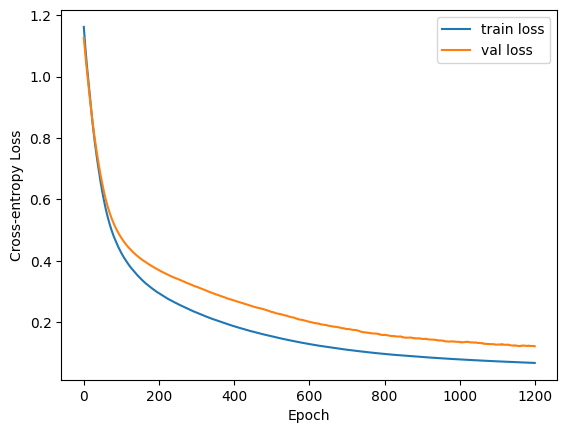

In [14]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load and prepare data
iris = load_iris()
X, y = iris.data, iris.target

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 4. Instantiate network
#    architecture: 4 inputs → 10 hidden units → 3 outputs (one per class)
nn = NeuralNetClassifier(layer_dims=[X_train.shape[1], 10, 3], init_method='xavier', lr=0.01)

# 5. Train
history = nn.train(
    X_train, y_train,
    X_val=X_test, y_val=y_test,
    epochs=1200, batch_size=32, verbose=True
)

# 6. Evaluate
y_pred = nn.predict(X_test)
acc = (y_pred == y_test).mean()
print(f"\nTest accuracy: {acc:.4f}")

# Step 6: Evaluate performance
y_pred = nn.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# 7. Plot loss curve (optional)
import matplotlib.pyplot as plt
plt.plot(history['loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy Loss')
plt.legend()
plt.show()


---
Test it against MLP classifier
---

In [15]:
from sklearn.neural_network import MLPClassifier

# Suppose your custom net is 12→10→1 with ReLU and sigmoid output:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(10,),    # one hidden layer of size 20
    activation='relu',           # ReLU in the hidden layer
    solver='sgd',                # stochastic gradient descent
    learning_rate_init=0.01,
    max_iter=1200,
    random_state=42
)
# Make sure y is 1D for MLPClassifier
mlp2.fit(X_train, y_train.ravel())


# scikit-learn predictions & scores
y_pred_skl = mlp2.predict(X_test)
acc_skl = (y_pred_skl == y_test).mean()

# custom net predictions & scores
y_pred_custom = np.round(nn.predict(X_test)).flatten()
acc_cust = (y_pred_custom == y_test).mean()
print()
print(f"SKL MLP —  acc: {classification_report(y_test, y_pred_skl)} \n")
print(f"Custom NN — acc: {classification_report(y_test, y_pred_custom)}")


SKL MLP —  acc:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.93      0.93      0.93        15
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45
 

Custom NN — acc:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

